# Fitting: Basics

**Goal**: Learn how to fit models to GW data using Ordinary Least Squares (OLS) and Generalized Least Squares (GLS).

GWexpy uses **iminuit** as its primary optimization engine and provides specialized cost functions for spectral data with correlations.

Install it with the `fitting` extra before running this notebook: `pip install "gwexpy[fitting]"`.


## 1. Simple OLS Fit

We start with a simple power-law fit using diagonal errors (OLS).


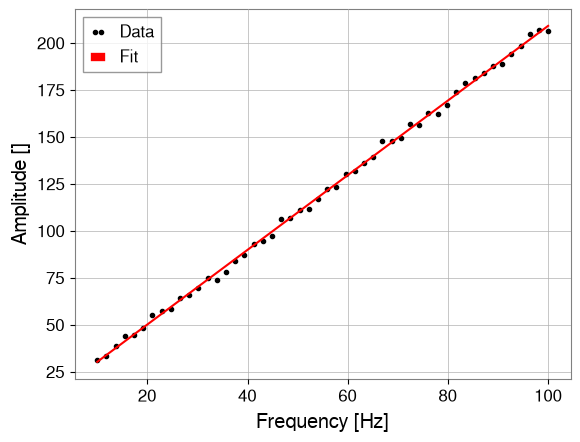

Fitted a=1.99, b=10.26


In [1]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import numpy as np
np.random.seed(42)

from gwexpy.fitting import fit_series

# Generate synthetic data
freqs = np.linspace(10, 100, 50)
model = lambda f, a, b: a * f + b
y_true = model(freqs, 2.0, 10.0)
y_obs = y_true + np.random.normal(0, 2, size=len(freqs))

from gwexpy.frequencyseries import FrequencySeries

psd = FrequencySeries(y_obs, frequencies=freqs)

res = fit_series(psd, model, p0={"a": 1.0, "b": 1.0})

res.plot()
plt.show()
print(f"Fitted a={res.params['a']:.2f}, b={res.params['b']:.2f}")

## 2. Generalized Least Squares (GLS)

When data points are correlated (e.g., in a PSD estimate with overlapping windows), we use the covariance matrix $\Sigma$.


In [2]:
from iminuit import Minuit

from gwexpy.fitting import GeneralizedLeastSquares

# Create a dummy covariance matrix
cov = np.eye(len(freqs)) * 4.0
cov_inv = np.linalg.inv(cov)

# 1. Define Cost Function
cost = GeneralizedLeastSquares(freqs, y_obs, cov_inv, model, cov=cov)

# 2. Initialize and Run Minuit
m = Minuit(cost, a=1.0, b=1.0)
m.migrad()

print(m.values)

<ValueView a=1.987114800112779 b=10.257738183268135>


## 3. High-level Integration

In real analysis, we often estimate the covariance matrix from the data itself using bootstrap methods. GWexpy provides an integrated pipeline for this.


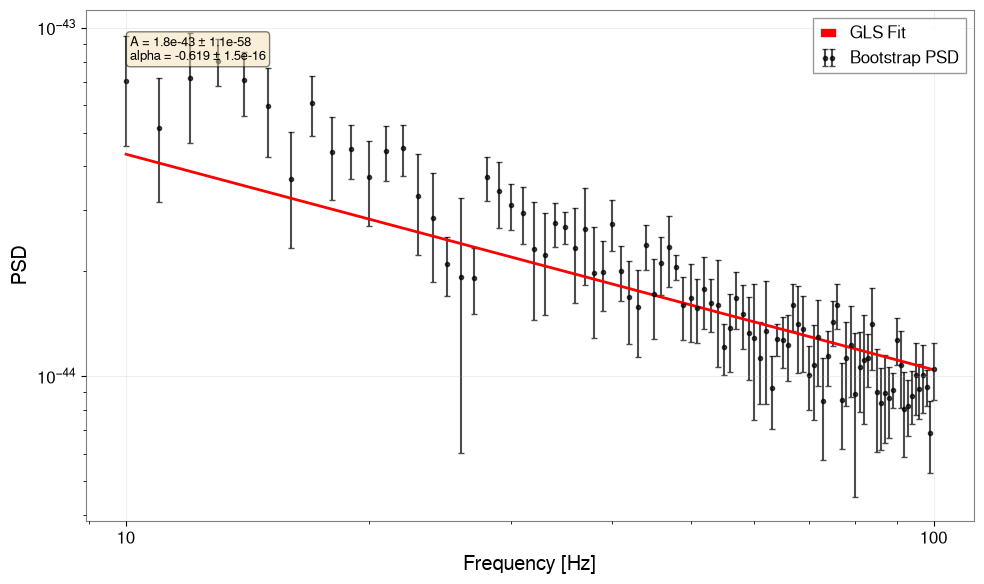

In [3]:
from gwexpy.fitting.highlevel import fit_bootstrap_spectrum
from gwexpy.noise.wave import colored

# Generate 10 seconds of pink noise
data = colored(duration=10, sample_rate=256, exponent=0.5, amplitude=1e-21)

def power_law(f, A, alpha):
    return A * f**alpha

result = fit_bootstrap_spectrum(
    data,
    model_fn=power_law,
    freq_range=(10, 100),
    fftlength=1.0,
    overlap=0.5,
    initial_params={"A": 1e-21, "alpha": -0.5},
    plot=True
)

## 4. Exercises

1. **Parameter Bounds**: Modify the OLS fit to restrict `a > 0` using the `limits` argument in `fit_series`.
2. **MCMC**: Enable MCMC in Section 3 by setting `run_mcmc=True` (requires `emcee`).


## 5. Quick Check (NBMAKE)


In [4]:
assert "a" in res.params
assert result.reduced_chi2 > 0
print("Validation successful!")

Validation successful!
